In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("../results")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

plt.rcdefaults()  # reset to matplotlib defaults first
plt.rcParams.update({
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'legend.frameon':    False,
    'figure.dpi':        150,
})

COLORS = {
    'synthetic': '#2166ac',
    'lightbox':  "#4f0942",
    'sunlamp':   '#d6604d',
}


In [16]:
LABELS = {
    'synthetic': 'Synthetic (validation)',
    'lightbox':  'Lightbox HIL',
    'sunlamp':   'Sunlamp HIL',
}

DOMAINS = ['synthetic', 'lightbox', 'sunlamp']

PROJECT_ROOT = Path('/Users/anjali/final_proj')
MAT_ROOT     = PROJECT_ROOT / 'spnv2/tools/outputs/efficientdet_d3/full_config'
RESULTS_DIR  = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

In [18]:
from scipy.io import loadmat
import numpy as np

mat_path = '/Users/anjali/Library/CloudStorage/OneDrive-Stanford/Coursework/Year 3/Spring/CS 229/final_proj/spnv2/tools/outputs/efficientdet_d3/full_config/lightbox/per_sample_performance.mat'

mat = loadmat(mat_path)

for k, v in mat.items():
    if not k.startswith('_'):
        arr = np.array(v)
        print(f"  {k}: shape={arr.shape}, mean={arr.mean():.4f}")

  heat_eR: shape=(1, 1001), mean=5.8953
  heat_eT: shape=(1, 1001), mean=0.1534
  heat_eR_HIL: shape=(1, 1001), mean=0.1029
  heat_eT_norm_HIL: shape=(1, 1001), mean=0.0246
  heat_pose: shape=(1, 1001), mean=0.1275
  effi_iou: shape=(1, 1001), mean=0.8816
  effi_eR: shape=(1, 1001), mean=7.2762
  effi_eT: shape=(1, 1001), mean=0.1657
  effi_eR_HIL: shape=(1, 1001), mean=0.1270
  effi_eT_norm_HIL: shape=(1, 1001), mean=0.0272
  effi_pose: shape=(1, 1001), mean=0.1542
  final_pose: shape=(0, 0), mean=nan
  h_reject: shape=(1, 1001), mean=0.0000


/var/folders/sv/4y94qp_x2c53cgsg_2b0kcxc0000gn/T/ipykernel_26229/2262533975.py:11: RuntimeWarning: Mean of empty slice
  print(f"  {k}: shape={arr.shape}, mean={arr.mean():.4f}")
/Users/anjali/Library/CloudStorage/OneDrive-Stanford/Coursework/Year 3/Spring/CS 229/final_proj/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
# Convert the SPNv2 inference ouput .mat files to CSV 
from scipy.io import loadmat
import pandas as pd
import numpy as np
from pathlib import Path

BASE        = Path('/Users/anjali/Library/CloudStorage/OneDrive-Stanford/Coursework/Year 3/Spring/CS 229/final_proj')
MAT_ROOT    = BASE / 'spnv2/tools/outputs/efficientdet_d3/full_config'
RESULTS_DIR = BASE / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

for domain in DOMAINS:
    mat = loadmat(str(MAT_ROOT / domain / 'per_sample_performance.mat'))

    heat_eR_HIL      = mat['heat_eR_HIL'].flatten()
    effi_eT_norm_HIL = mat['effi_eT_norm_HIL'].flatten()
    effi_eT          = mat['effi_eT'].flatten()
    heat_eR          = mat['heat_eR'].flatten()
    h_reject         = mat['h_reject'].flatten()

    # align to shortest array in case of mismatched lengths
    n = min(len(heat_eR_HIL), len(effi_eT_norm_HIL),
            len(effi_eT), len(heat_eR), len(h_reject))

    print(f"{domain}: array lengths "
          f"heat_eR_HIL={len(heat_eR_HIL)}, "
          f"effi_eT_norm_HIL={len(effi_eT_norm_HIL)}, "
          f"n={n}")

    df = pd.DataFrame({
        'speed_score': heat_eR_HIL[:n] + effi_eT_norm_HIL[:n],
        'E_T':         effi_eT[:n],
        'E_R':         heat_eR[:n],
        'rejected':    h_reject[:n].astype(int),
    })

    df.to_csv(RESULTS_DIR / f'per_image_errors_{domain}.csv', index=False)
    print(f"  rows={len(df)}, mean speed_score={df.speed_score.mean():.3f}, "
          f"E_T={df.E_T.mean():.3f}m, E_R={df.E_R.mean():.1f}deg")

synthetic: array lengths heat_eR_HIL=1001, effi_eT_norm_HIL=1001, n=1001
  rows=1001, mean speed_score=0.024, E_T=0.050m, E_R=0.9deg
lightbox: array lengths heat_eR_HIL=1001, effi_eT_norm_HIL=1001, n=1001
  rows=1001, mean speed_score=0.130, E_T=0.166m, E_R=5.9deg
sunlamp: array lengths heat_eR_HIL=999, effi_eT_norm_HIL=1001, n=999
  rows=999, mean speed_score=0.229, E_T=0.210m, E_R=11.1deg


In [25]:
data = {}
for domain in DOMAINS:
    path = RESULTS_DIR / f'per_image_errors_{domain}.csv'
    if not path.exists():
        print(f"Missing: {path}")
    else:
        data[domain] = pd.read_csv(path)
        print(f"{domain:12s}: {len(data[domain]):,} images | "
              f"mean E_pose={data[domain]['speed_score'].mean():.3f} | "
              f"mean E_T={data[domain]['E_T'].mean():.3f}m | "
              f"mean E_R={data[domain]['E_R'].mean():.1f}°")

synthetic   : 1,001 images | mean E_pose=0.024 | mean E_T=0.050m | mean E_R=0.9°
lightbox    : 1,001 images | mean E_pose=0.130 | mean E_T=0.166m | mean E_R=5.9°
sunlamp     : 999 images | mean E_pose=0.229 | mean E_T=0.210m | mean E_R=11.1°


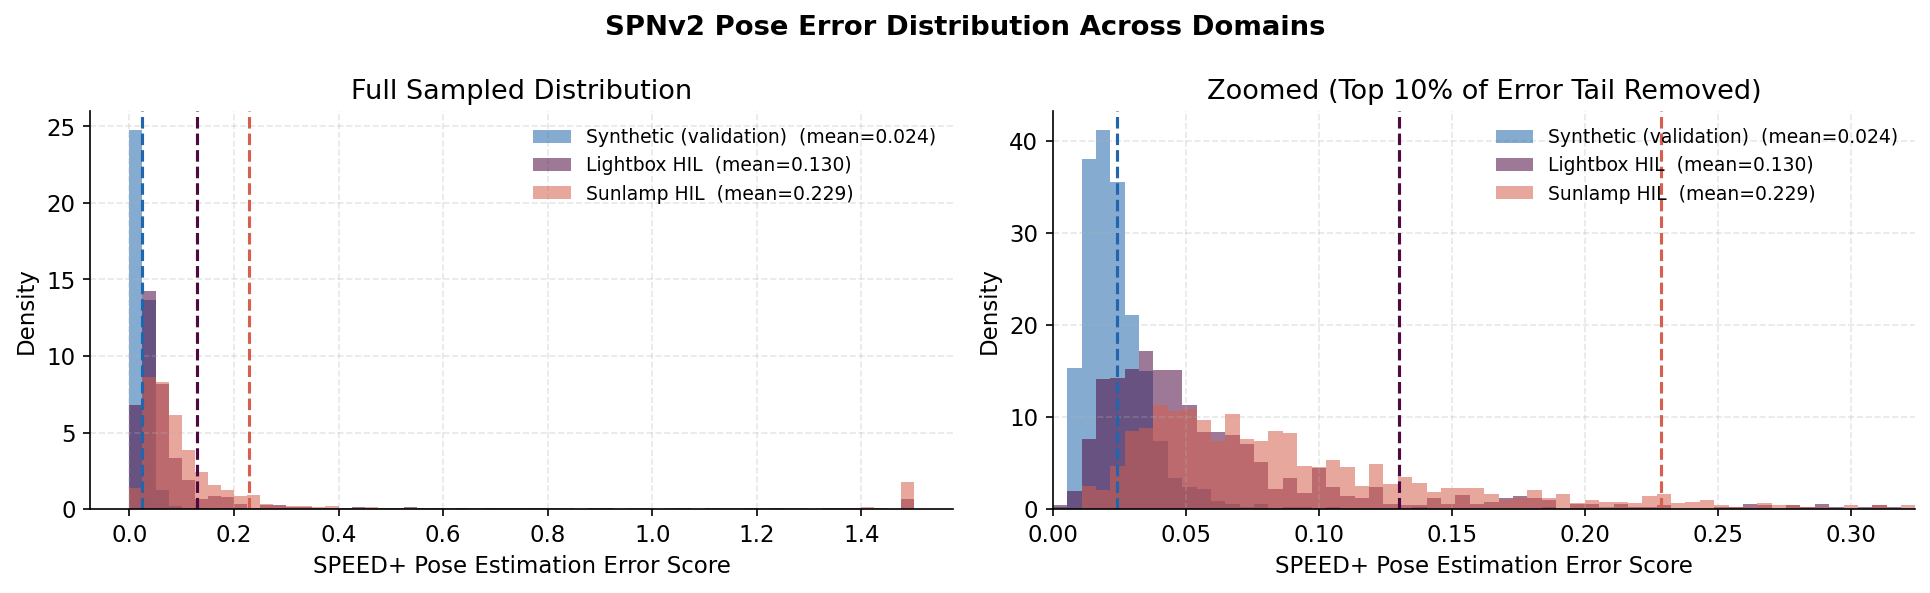

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

cap = max(np.percentile(data[d]['speed_score'], 90) for d in DOMAINS if d in data)

for domain in DOMAINS:
    if domain not in data:
        continue
    vals = data[domain]['speed_score']
    label = f"{LABELS[domain]}  (mean={vals.mean():.3f})"

    # Left: full distribution
    ax1.hist(vals.clip(0, 1.5), bins=60, range=(0, 1.5),
             color=COLORS[domain], alpha=0.55, label=label,
             density=True, edgecolor='none')
    ax1.axvline(vals.mean(), color=COLORS[domain], linestyle='--', linewidth=1.5)

    # Right: zoomed, top-10% tail removed
    inliers = vals[vals <= cap]
    ax2.hist(inliers, bins=60, range=(0, cap),
             color=COLORS[domain], alpha=0.55, label=label,
             density=True, edgecolor='none')
    ax2.axvline(vals.mean(), color=COLORS[domain], linestyle='--', linewidth=1.5)

ax1.set_xlabel('SPEED+ Pose Estimation Error Score')
ax1.set_ylabel('Density')
ax1.set_title('Full Sampled Distribution')
ax1.legend(fontsize=9)

ax2.set_xlim(0, cap)
ax2.set_xlabel('SPEED+ Pose Estimation Error Score')
ax2.set_ylabel('Density')
ax2.set_title('Zoomed (Top 10% of Error Tail Removed)')
ax2.legend(fontsize=9)

fig.suptitle('SPNv2 Pose Error Distribution Across Domains', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pose_error_dist.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'pose_error_dist.png', bbox_inches='tight')
plt.show()


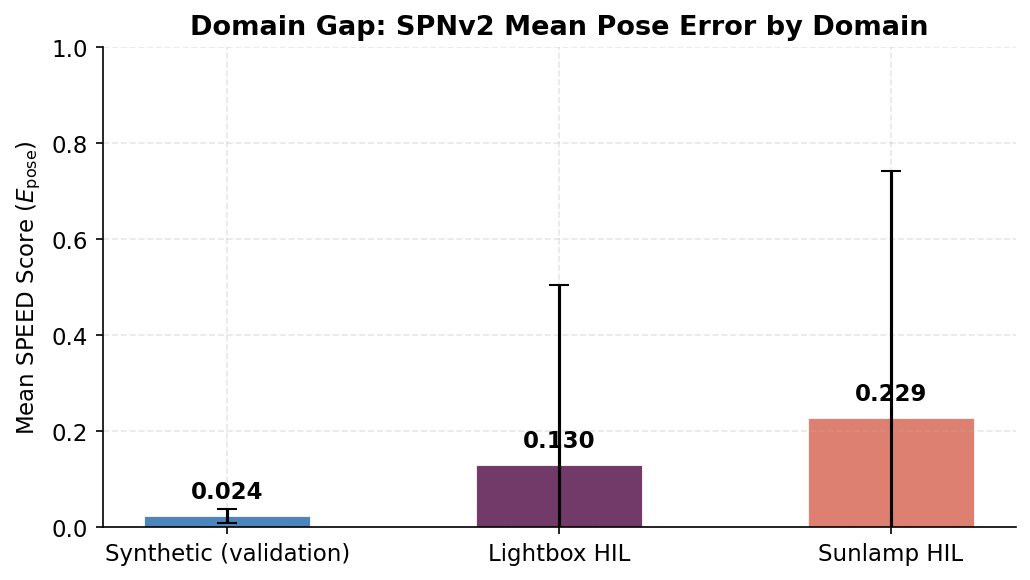

In [43]:
# ── Figure 3: Domain Gap Summary Bar Chart ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

domain_list = [d for d in DOMAINS if d in data]
means  = [data[d]['speed_score'].mean() for d in domain_list]
stds   = [data[d]['speed_score'].std()  for d in domain_list]
colors = [COLORS[d] for d in domain_list]
xlabels = [LABELS[d] for d in domain_list]

bars = ax.bar(xlabels, means, color=colors, alpha=0.8,
              edgecolor='white', linewidth=0.5, width=0.5)
ax.errorbar(xlabels, means, yerr=stds,
            fmt='none', color='black', capsize=5, linewidth=1.5)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(stds) * 0.05,
            f'{mean:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_ylabel('Mean SPEED Score ($E_{\\mathrm{pose}}$)')
ax.set_title('Domain Gap: SPNv2 Mean Pose Error by Domain',
             fontweight='bold')
ax.set_ylim(0, max(means) + max(stds) * 1.5)

plt.tight_layout()
# plt.savefig(FIGURES_DIR / 'domain_gap_bar.pdf', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / 'domain_gap_bar.png', bbox_inches='tight')
plt.show()
# print("Saved → figures/domain_gap_bar.pdf")